# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**Ответ:**
1. $\Omega_1 = \{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$

**Выпукло.**

Пусть $x=(x_1,x_2),\,y=(y_1,y_2)\in\Omega_1$, т.е. $x_2\ge x_1^2$, $y_2\ge y_1^2$.

$z=(1-t)x+ty$. Тогда:
$$
z_2 = (1-t)x_2+t y_2 \;\ge\; (1-t)x_1^2+t y_1^2 .
$$
Квадрат от функции выпуклое преобразование по критерию 2го порядка, поэтому $(1-t)x_1^2+t y_1^2 \ge \big((1-t)x_1+t y_1\big)^2 = z_1^2$. Значит $z_2\ge z_1^2$, т.е. $z\in\Omega_1$. Отрезок между любыми двумя точками лежит в $\Omega_1$. Выпукло по определению

Вириант 2: выпукло как надграфик выпуклой функции квадрат

2. $\Omega_2 = \{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$, $A\in\mathbb{R}^{m\times n}$, $b\in\mathbb{R}^m$

**Выпукло.**

Пусть $x,y\in\Omega_2$, т.е. $\Vert Ax-b\Vert\le 1$, $\Vert Ay-b\Vert\le 1$. Для $t\in[0,1]$
$$
\big\Vert A\big((1-t)x+ty\big)-b\big\Vert
= \big\Vert (1-t)(Ax-b)+t(Ay-b)\big\Vert
\le (1-t)\Vert Ax-b\Vert + t\Vert Ay-b\Vert
\le (1-t)+t = 1 .
$$
(неравенство треугольника и положительная определенность нормы)

то есть отрезок между любыми двумя точками из $\Omega_2$ лежит в $\Omega_2$. $\Omega_2$ - выпукло по определению

3. $\Omega_3 = \{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$

**Не выпукло.**

Контрпример.
$$
x = (1, 0), \qquad y = (-1, 0).
$$
Обе точки лежат в $\Omega_3$: $\Vert x\Vert_2 = \Vert y\Vert_2 = 1 \ge 1$. Но их середина
$$
z = \tfrac12 x + \tfrac12 y = (0, 0)
$$
имеет норму $\Vert z\Vert_2 = 0 < 1$, значит $z\notin \Omega_3$. Отрезок не содержится в $\Omega_3$, не выпукло

**(б)**

**Ответ:**

$f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$,
ее гессиан:
$$
\nabla f(x) = \begin{pmatrix} 2x_1 + a x_2 \\ a x_1 + 2x_2 \end{pmatrix},
\qquad
\nabla^2 f(x) = \begin{pmatrix} 2 & a \\ a & 2 \end{pmatrix} - обозначим H.
$$

Матрица $H$ **симметрична** ($H = H^\top$) и **не зависит от $x$**. Для симметричных матриц верна спектральная теорема, из которой следует эквивалентность
$$
H \succeq 0 \iff \lambda_{\min}(H) \ge 0, \qquad H \succ 0 \iff \lambda_{\min}(H) > 0 .
$$
Так как $H$ — константа, проверка этого матричного неравенства автоматически даёт выполнение критерия второго порядка (раздел 4 конспекта) **на всём** $\mathbb{R}^2$, а не в отдельной точке.

Собственные векторы $(1,1)^\top$ и $(1,-1)^\top$ дают
$$
H\binom{1}{1} = (2+a)\binom{1}{1}, \qquad H\binom{1}{-1} = (2-a)\binom{1}{-1},
$$
то есть
$$
\lambda_{1,2} = 2 \mp a, \qquad \lambda_{\min}(H) = 2 - |a|
$$

**Выпуклость.** По критерию второго порядка $f$ выпукла на $\mathbb{R}^2$ тогда и только тогда, когда $H \succeq 0$, т.е. оба собственных числа неотрицательны:
$$
2 - a \ge 0 \quad\text{и}\quad 2 + a \ge 0 \iff -2 \le a \le 2 .
$$
При $|a| > 2$ имеем $\lambda_{\min} < 0$, значит $H$ индефинитна и $f$ не выпукла и не вогнута.

**Строгая выпуклость.** Если $H \succ 0$, то $\nabla^2 f \succ 0$ всюду; это достаточное условие строгой выпуклости. Оба собственных числа строго положительны:
$$
2 - a > 0 \quad\text{и}\quad 2 + a > 0 \iff -2 < a < 2
$$

**Граница $a = \pm 2$.** Здесь $\det H = 4 - a^2 = 0$, матрица вырождена: одно собственное число $0$, второе $4$, значит $H \succeq 0$, но $H \not\succ 0$. По критерию второго порядка $f$ выпукла, но достаточное условие строгой выпуклости не выполнено. При $a = 2$:
$$
f(x) = x_1^2 + 2x_1 x_2 + x_2^2 = (x_1 + x_2)^2 ,
$$
и $f \equiv 0$ на прямой $x_1 + x_2 = 0$. Для строго выпуклой функции из $x \ne y$ и $t \in (0,1)$ требуется
$$
f\big((1-t)x + ty\big) < (1-t) f(x) + t f(y) ;
$$
здесь на указанной прямой стоит равенство — противоречие. При $a = -2$ аналогично $f = (x_1 - x_2)^2$ постоянна на прямой $x_1 = x_2$. Значит, при $a = \pm 2$ функция выпукла, но **не** строго выпукла.



2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

Нет, не выпукла.
$$
g(x) = x_1^2 x_2^2, \qquad
\nabla g(x) = \begin{pmatrix} 2x_1 x_2^2 \\ 2x_1^2 x_2 \end{pmatrix},
$$
$$
\nabla^2 g(x) = \begin{pmatrix} 2x_2^2 & 4x_1 x_2 \\ 4x_1 x_2 & 2x_1^2 \end{pmatrix}.
$$
Определитель:
$$
\det \nabla^2 g(x) = 4x_1^2 x_2^2 - 16 x_1^2 x_2^2 = -12\,x_1^2 x_2^2 .
$$
Матрица гессиана g симметрична. При $x_1 \ne 0$ и $x_2 \ne 0$ определитель отрицателен. У симметричной матрицы $2\times 2$ с отрицательным определителем собственные числа разных знаков, значит $\nabla^2 g(x) \not\succeq 0$ - ессиан не является положительно полуопределённым. По критерию второго порядка $g$ не выпукла

In [2]:
# численная проверка а
for a in [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]:
    H = np.array([[2.0, a], [a, 2.0]])
    eigs = np.linalg.eigvalsh(H)
    print(f"a = {a:5.1f}:  собственные = {eigs},  выпуклость = {bool(np.all(eigs >= -1e-12))}")


a =  -3.0:  собственные = [-1.  5.],  выпуклость = False
a =  -2.0:  собственные = [0. 4.],  выпуклость = True
a =  -1.0:  собственные = [1. 3.],  выпуклость = True
a =   0.0:  собственные = [2. 2.],  выпуклость = True
a =   1.0:  собственные = [1. 3.],  выпуклость = True
a =   2.0:  собственные = [0. 4.],  выпуклость = True
a =   3.0:  собственные = [-1.  5.],  выпуклость = False


In [3]:
# численная проверка б
def f(x1, x2):
    return np.array([[2 * x2**2, 4 * x1 * x2],[4 * x1 * x2, 2 * x1**2]])

for x1, x2 in [(1.0, 1.0), (2.0, -1.0), (0.5, 3.0)]:
    eigs = np.linalg.eigvalsh(f(x1, x2))
    print(f"x = ({x1}, {x2}):  собственные = {eigs},  выпуклость = {bool(np.all(eigs >= -1e-12))}")

x = (1.0, 1.0):  собственные = [-2.  6.],  выпуклость = False
x = (2.0, -1.0):  собственные = [-3.54400375 13.54400375],  выпуклость = False
x = (0.5, 3.0):  собственные = [-1.35954759 19.85954759],  выпуклость = False


**(в)**

**Ответ:**
1. **Выпукла.**

- $\|Ax-b\|_2$ выпукла: композиция нормы (выпукла) с аффинным $x \mapsto Ax-b$
- $\|x\|_\infty$ выпукла как максимум выпуклых функций $|x_{i}|$
- $\lambda \ge 0$: умножение на неотрицательный скаляр сохраняет выпуклость
- Сумма двух выпуклых $\|Ax-b\|_2$  и  $\lambda\|x\|_\infty$ выпукла
 2. **Выпукла.**

- Каждое слагаемое $(a_i^\top x - b_i)^2$ выпукло: композиция выпуклой $u \mapsto u^2$ с аффинным $u = a_i^\top x - b_i$
- Поточечный максимум выпуклых функций выпукл. Значит, $f$ выпукла

3. **Не выпукла.**

Контрпример. Возьмём $n = 1$ и точки
$$
x = -1, \qquad y = 1.
$$
Тогда
$$
f(-1) = e^{-1}, \qquad f(1) = e^{-1},
$$
а в середине $z = 0$:
$$
f(0) = e^{0} = 1.
$$
Для выпуклости требовалось бы
$$
f(0) \le \tfrac12 f(-1) + \tfrac12 f(1) = e^{-1} \approx 0.368,
$$
но $< 1$. Определение нарушено.

Правила раздела 5 не применимы: это композиция
убывающей функции $e^{-x}$ с выпуклой функцией ||x||. правило из раздела 5 требует, чтобы внешняя функция была не убывающей.

Гладкая только третья.

$\|Ax-b\|_2$ не дифференцируема в точках, где $Ax = b$, так как не дифференцируема в нуле. $\|x\|_\infty$ не дифференцируема там, где две координаты равны по модулю: $|x_i| = |x_j| \ge |x_k|$. В таких точках у $\|x\|_\infty$ излом.

Каждое $g_i(x) = (a_i^\top x - b_i)^2$ — многочлен, гладкий всюду. Но поточечный максимум гладких функций, вообще говоря, гладким не является: в точках, где максимум достигается на нескольких индексах с разными градиентами, возникает излом. Для общих $(a_i, b_i)$ такие точки существуют, поэтому $f_2$ в общем случае не гладкая.

Суперпозиция гладких: $x \mapsto \sum_k x_k^2$ — многочлен; $u \mapsto e^{-u}$ — экспонента, гладкая. Композиция $C^\infty$-функций $C^\infty$.

**(г)**


Ответ:

(а)
- Цель $f(x) = (x_1 - 1)^2 + (x_2 - 2)^2 + (x_3 - 3)^2$ — сумма квадратов, гессиан $2I \succ 0$ — строго выпукла.
- Равенства $g(x) = (x_1 + x_2 + x_3 - 1,\ x_1 - x_3) = 0$ — аффинные, их множество решений (прямая) — аффинное подпространство, всегда выпуклое.
 - Неравенств нет.

Все три пункта чек-листа выполнены — задача выпукла.Класс: QP с ограничениями-равенствами.

(б)
- Цель $f(x) = c^\top x$ — линейная, выпукла и вогнута при любом $c$.
- Равенств нет.
- Неравенства $h(x) = (Ax - b,\ x) \ge 0$ — аффинные функции координат $x$, их допустимое множество — пересечение полупространств, выпуклое.

Задача выпукла.Класс: LP.

(в)
- Цель $f(x) = -4ab$
- Гессиан
$$
\nabla^2 f = \begin{pmatrix} 0 & -4 \\ -4 & 0 \end{pmatrix}, \qquad \lambda_{1,2} = \pm 4,
$$
знаконеопределённый — по критерию второго порядка $f$ не выпукла (и не вогнута). Неравенство $1-a^2-b^2 \ge 0$ задано вогнутой функцией, множество выпукло. Выпуклость ломается целевой функцией.

(г)
Сумма квадратов $\sum_i r_i(x)^2$ выпукла, только если каждое $r_i$ аффинно (правило раздела 5); здесь $r_i(x) = x_1 \sin(x_2 t_i + x_3) - y_i$ не аффинно — параметры $x_2, x_3$ стоят внутри $\sin$. Контрпример: при $N=1$, $t_1=0$, $y_1=0$, $x_2=0$ функция сводится к $f = x_1^2 \sin^2(x_3)$; точки $p=(1,0,0)$ и $q=(0,0,\pi/2)$ дают $f(p)=f(q)=0$, а середина $z=(1/2, 0, \pi/4)$ даёт $f(z) = 1/8 > 0$ — неравенство хорды нарушено. Выпуклость ломает нелинейность модели по параметрам.

(д)
Переформулировка с дополнительной переменной $s$:
$$
\min_{(x,s)} s \quad \text{при} \quad s \ge a_i^\top x - b_i, \quad s \ge -(a_i^\top x - b_i), \quad i = 1, \dots, m .
$$

Стандартная форма:
$$
(x, s) \in \mathbb{R}^{n+1}, \quad f(x, s) = s, \quad g = \varnothing, \quad h(x, s) = \bigl(s - (a_i^\top x - b_i),\ s + (a_i^\top x - b_i)\bigr)_{i=1}^m \ge 0 .
$$

 - Цель $f(x, s) = s$ — линейная, выпукла.
 - Равенств нет.
  - Неравенства $h(x, s) = (s - (a_i^\top x - b_i),\ s + (a_i^\top x - b_i)) \ge 0$ — аффинные по $(x, s)$, допустимое множество — пересечение полупространств, выпуклое.

  Задача выпукла (LP).

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [4]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

**Ответ:**
i) $x^\ast$ лежит на границе. Пусть $a^\top x^\ast < b$. Тогда при малом $t > 0$ точка $y = x^\ast + t(p - x^\ast)$ допустима, и $(x^\ast - p)^\top(y - x^\ast) = -t\|p - x^\ast\|^2 \le 0$, причём строго $< 0$, если $x^\ast \ne p$. Это противоречит условию оптимальности, значит $x^\ast = p$, но $p \notin \Omega$. Значит, $a^\top x^\ast = b$.

(ii) Для любого $v$ с $a^\top v = 0$ точки $y_\pm = x^\ast \pm v$ допустимы. Подстановка в условие оптимальности даёт $(x^\ast - p)^\top v \ge 0$ и одновременно $\le 0$, значит $(x^\ast - p)^\top v = 0$. Вектор $x^\ast - p$ ортогонален $\{a\}^\perp$, значит лежит в $\mathrm{span}\{a\}$: $x^\ast = p + \lambda a$ для некоторого $\lambda$.

(iii) Подставляем в $a^\top x^\ast = b$: $a^\top p + \lambda \|a\|^2 = b$, откуда $\lambda = -(a^\top p - b)/\|a\|^2$. Обозначим $\alpha = (a^\top p - b)/\|a\|^2 > 0$. Получаем
$$
x^\ast = p - \frac{a^\top p - b}{\|a\|^2}\, a .
$$
(iv) Проверка. При найденном $x^\ast$ имеем $x^\ast - p = -\alpha a$ с $\alpha > 0$. Для любого $y \in \Omega$:
$$
(x^\ast - p)^\top(y - x^\ast) = -\alpha\,a^\top(y - x^\ast) = \alpha\,(b - a^\top y) \ge 0,
$$
так как $a^\top y \le b$. Условие оптимальности выполнено для всех $y \in \Omega$, значит $x^\ast$ — глобальное решение.

**Численная проверка (пункты 2 и 3)**

In [5]:
c = (a @ p - b) / (a @ a)
x_star = p - c * a
print(f"c = {c:.6f}")
print(f"x* (формула) = {x_star}")
print(f"a @ x* = {a @ x_star:.6f}")
print(f"||x* - p|| = {np.linalg.norm(x_star - p):.6f}")

def f(x):    return 0.5 * np.sum((x - p) ** 2)
def grad(x): return x - p

cons = [{'type': 'ineq',
         'fun': lambda x: b - a @ x,
         'jac': lambda x: -a}]

res = minimize(f, np.zeros(3), method='SLSQP', jac=grad, constraints=cons, options={'ftol': 1e-12, 'maxiter': 1000})
print(f"\nSLSQP x* = {res.x}")
print(f"SLSQP f  = {res.fun:.8f},  формула f = {f(x_star):.8f}")
print(f"success = {res.success}, ||SLSQP - формула|| = {np.linalg.norm(res.x - x_star):.2e}")

rng = np.random.default_rng(0)
N = 2000
Z = rng.standard_normal((N, 3)) * 5.0
az = Z @ a
Y = Z.copy()
mask = az > b
Y[mask] = Z[mask] - ((az[mask] - b) / (a @ a))[:, None] * a
assert (Y @ a <= b + 1e-12).all()
print(f"\nmax(a^T Y) = {(Y @ a).max():.6e}  (<= b = {b})")

def check_opt(x, label):
    g = x - p
    vals = (Y - x) @ g
    ok = vals.min() >= -1e-8
    print(f"{label:>20}: min = {vals.min(): .4e},  mean = {vals.mean(): .4e},  "
          f"max = {vals.max(): .4e}  ->  "
          f"{'условие ВЫПОЛНЕНО' if ok else 'условие НАРУШЕНО'}")

check_opt(x_star, "x* (формула)")
check_opt(res.x, "x* (SLSQP)")
check_opt(np.zeros(3), "x = 0")
check_opt(p, "x = p")

print(f"\nf(x*) = {f(x_star):.6f}")
print(f"min_y grad^T(y - x*) = {((Y - x_star) @ (x_star - p)).min(): .4e}")
print(f"min_y grad^T(y - 0)  = {((Y - np.zeros(3)) @ (np.zeros(3) - p)).min(): .4e}")

c = 0.583333
x* (формула) = [ 2.41666667 -0.16666667  1.08333333]
a @ x* = 1.000000
||x* - p|| = 1.428869

SLSQP x* = [ 2.41666667 -0.16666667  1.08333333]
SLSQP f  = 1.02083333,  формула f = 1.02083333
success = True, ||SLSQP - формула|| = 8.31e-16

max(a^T Y) = 1.000000e+00  (<= b = 1.0)
        x* (формула): min = -4.4409e-15,  mean =  3.1368e+00,  max =  2.5418e+01  ->  условие ВЫПОЛНЕНО
          x* (SLSQP): min = -5.9952e-15,  mean =  3.1368e+00,  max =  2.5418e+01  ->  условие ВЫПОЛНЕНО
               x = 0: min = -3.9594e+01,  mean =  3.6876e+00,  max =  5.5345e+01  ->  условие НАРУШЕНО
               x = p: min =  0.0000e+00,  mean =  0.0000e+00,  max =  0.0000e+00  ->  условие ВЫПОЛНЕНО

f(x*) = 1.020833
min_y grad^T(y - x*) = -4.4409e-15
min_y grad^T(y - 0)  = -3.9594e+01


**Ответ:**
Численная проекция (SLSQP) совпала с формулой с точностью
$8.31 \times 10^{-16}$ — на уровне машинной погрешности.

Проверка условия оптимальности: в $x^\ast$ минимум
$\nabla f(x^\ast)^\top (y - x^\ast)$ по 2000 случайным допустимым $y$
практически ноль ($-4.44 \times 10^{-15} \approx 0$), как и требуется.Проверка условия оптимальности проводилась сэмплированием 2000 случайных допустимых точек из куба $[-5, 5]^3$.
В $x = 0$ (допустима, но не оптимальна) минимум сильно отрицателен
($-39.59$). Это значит, есть допустимое направление, уменьшающее $f$,то есть $x = 0$ не минимум.

**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

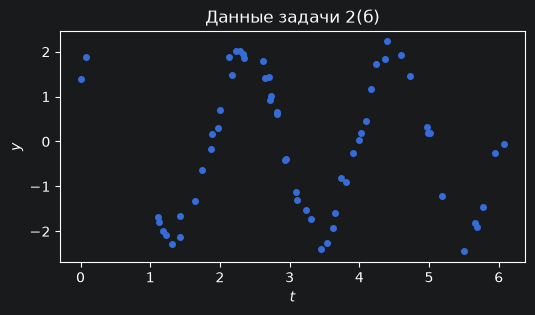

In [6]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ**

Модель B. $\varphi_B(t; x) = x_1 \sin \omega t + x_2 \cos \omega t$ при известной $\omega$ линейна по $x$, поэтому $f(x) = \tfrac12 \|Ax - y\|^2$ с $A_i = (\sin \omega t_i,\ \cos \omega t_i)$ — квадратичная форма с $Q = A^\top A \succeq 0$ (матрица Грама). Класс: безусловная QP, выпуклая; строго выпуклая при $\operatorname{rank}(A) = 2$, что здесь выполнено.

Модель A. $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$ нелинейна по $x_2, x_3$ (внутри синуса), нет представления $\varphi_A = Ax$. Класс: безусловная нелинейная NLP (нелинейный МНК).

Невыпукла. Из периодичности $\sin(\theta + 2\pi) = \sin\theta$:
$$
f(x_1, x_2, x_3 + 2\pi) = f(x_1, x_2, x_3) \quad \forall x .
$$
Из знаковой симметрии $\sin(\theta + \pi) = -\sin\theta$ получаем
$$
f(-x_1, x_2, x_3 + \pi) = f(x_1, x_2, x_3) \quad \forall x .
$$
Значит, если $x^\ast$ — глобальный минимум, то и точки $(x_1^\ast, x_2^\ast, x_3^\ast + 2\pi k)$, $k \in \mathbb{Z}$, и их «зеркальные» $(-x_1^\ast, x_2^\ast, x_3^\ast + \pi)$ тоже глобальные минимумы. Но в середине отрезка между $x^\ast$ и $(x_1^\ast, x_2^\ast, x_3^\ast + 2\pi)$ лежит точка $(x_1^\ast, x_2^\ast, x_3^\ast + \pi)$, в которой синус меняет знак: невязка меняется с $r_i = x_1^\ast \sin(x_2^\ast t_i + x_3^\ast) - y_i$ на $-\bigl(x_1^\ast \sin(x_2^\ast t_i + x_3^\ast)\bigr) - y_i$, то есть $f$ в этой точке строго больше $f^\ast$ (при ненулевом сигнале). Если бы $f$ была выпуклой, множество подуровня $\{f \le f^\ast\}$ было бы выпуклым и весь отрезок между двумя глобальными минимумами лежал бы в нём, то есть $f$ была бы равна $f^\ast$ на всём отрезке. Противоречие. Значит, $f$ не выпукла.

**Мультистарт (пункт 2)**

Модель A: значения f по 20 стартам
[ 1.1393 63.8249  1.1393  1.1393  1.1393 61.4973 61.4973 64.2518  1.1393
 63.8249  1.1393  1.1393 61.4973  1.1393 64.2518  1.1393 61.6882  1.1393
 61.4973  1.1393]

Модель B: значения f по 20 стартам
[1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408
 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408]

Наименьшее f_A = 1.139273, доля стартов, дошедших до него: 0.55
Наименьшее f_B = 1.140764, доля стартов, дошедших до него: 1.00


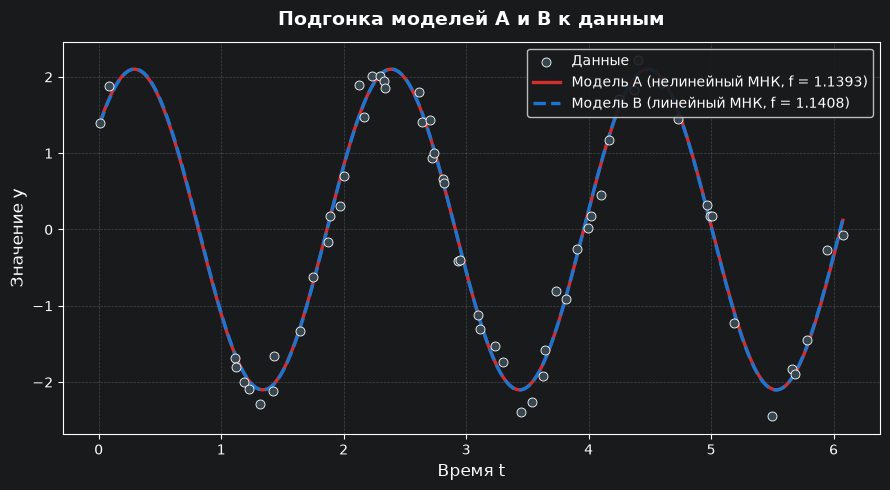

In [7]:
def f_A(x, t=t, y=y):
    return 0.5 * np.sum((x[0] * np.sin(x[1] * t + x[2]) - y) ** 2)

def f_B(x, t=t, y=y, omega=omega):
    return 0.5 * np.sum((x[0] * np.sin(omega * t) + x[1] * np.cos(omega * t) - y) ** 2)

fA_vals = np.zeros(len(starts))
fB_vals = np.zeros(len(starts))
xA_sols = []
xB_sols = []

for k, x0 in enumerate(starts):
    resA = minimize(f_A, x0, method="BFGS")
    resB = minimize(f_B, x0[:2], method="BFGS")
    fA_vals[k] = resA.fun
    fB_vals[k] = resB.fun
    xA_sols.append(resA.x)
    xB_sols.append(resB.x)

print("Модель A: значения f по 20 стартам")
print(np.round(fA_vals, 4))
print("\nМодель B: значения f по 20 стартам")
print(np.round(fB_vals, 4))

tol = 1e-4
best_A, best_B = fA_vals.min(), fB_vals.min()
frac_A = np.mean(fA_vals < best_A + tol)
frac_B = np.mean(fB_vals < best_B + tol)
print(f"\nНаименьшее f_A = {best_A:.6f}, доля стартов, дошедших до него: {frac_A:.2f}")
print(f"Наименьшее f_B = {best_B:.6f}, доля стартов, дошедших до него: {frac_B:.2f}")

x_best_A = xA_sols[int(np.argmin(fA_vals))]
x_best_B = xB_sols[int(np.argmin(fB_vals))]

t_plot = np.linspace(t.min(), t.max(), 400)
yA_plot = x_best_A[0] * np.sin(x_best_A[1] * t_plot + x_best_A[2])
yB_plot = x_best_B[0] * np.sin(omega * t_plot) + x_best_B[1] * np.cos(omega * t_plot)

fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(t, y, s=42, color="#37474F", edgecolor="white", linewidth=0.6,
           label="Данные", zorder=3)
ax.plot(t_plot, yA_plot, color="#D32F2F", linewidth=2.4,
        label=f"Модель A (нелинейный МНК, f = {best_A:.4f})", zorder=2)
ax.plot(t_plot, yB_plot, color="#1976D2", linewidth=2.4, linestyle="--",
        label=f"Модель B (линейный МНК, f = {best_B:.4f})", zorder=2)

ax.set_title("Подгонка моделей A и B к данным",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Время t", fontsize=12)
ax.set_ylabel("Значение y", fontsize=12)
ax.legend(loc="upper right", fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle="--")


plt.tight_layout()
plt.show()

**Объяснение (пункт 3)**

**Ответ:**


**Главная теорема:** для выпуклой дифференцируемой функции любой локальный минимум — глобальный; для строго выпуклой — он единственен; градиентный метод сходится к нему из любой точки.

- **B** строго выпукла - теорема применима - **100% стартов** сходятся к единственному минимуму.
- **A** невыпукла - теорема **неприменима** - BFGS сходится в тот минимум, в чью область влияния попал старт - **55% успеха**

Как из B получить амплитуду и фазу A

$$R\sin(\omega t + \varphi) = R\cos\varphi\,\sin(\omega t) + R\sin\varphi\,\cos(\omega t)$$

Сравнивая с B: $x_0^B = R\cos\varphi$, $x_1^B = R\sin\varphi$, откуда

$$\boxed{R = \sqrt{(x_0^B)^2 + (x_1^B)^2}, \qquad \varphi = \operatorname{atan2}(x_1^B,\ x_0^B)}$$

Почему $f_A < f_B$

**Почему меньше.** Модель B получается из A фиксацией частоты при $x_1 = \omega$. Минимум по большему множеству не превосходит минимум по меньшему:
$$
\min_{x \in \mathbb{R}^3} f_A(x) \;\le\; \min_{x \in \mathbb{R}^2} f_B(x).
$$

**Почему A не лучше:**

Меньшее значение $f_A$ на обучающей выборке — не критерий качества модели. Оно объясняется:
**переобучением.** A подстраивает частоту под шум конкретной выборки; истинная частота известна и равна 3. С ростом $N$ выигрыш исчезает, и A сходится к B.

Дополнительный недостаток A — невыпуклость. Даже если оптимизатор нашёл хороший минимум, он не гарантирует глобальность, и результат зависит от старта

Таким образом, хотя  $f_A < f_B$, модель A не лучше модели B: выигрыш статистически незначим, а сама оптимизация ненадёжна. Если частота действительно известна из физики задачи — правильно использовать модель B: она даёт гарантированно глобальный минимум из любого старта, не переобучается и лучше обобщается на новые данные.

## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ:**
Обозначим $a = P(p)$, $b = P(q)$, $u = a - b$. Запишем условия оптимальности для обеих проекций.

**Для $a = P(p)$.** Градиент целевой функции $\tfrac12\|x - p\|^2$ равен $x - p$. Условие оптимальности на выпуклом множестве — вариационное неравенство:

$$(a - p)^\top (y - a) \ge 0 \quad \forall y \in \Omega.$$

Подставим пробную точку $y = b \in \Omega$:

$$(a - p)^\top (b - a) \ge 0. \tag{1}$$

**Для $b = P(q)$.** Аналогично с пробной точкой $y = a \in \Omega$:

$$(b - q)^\top (a - b) \ge 0. \tag{2}$$

**Сложим (1) и (2).** Учитывая $b - a = -u$ и $a - b = u$, получаем:

$$-(a - p)^\top u + (b - q)^\top u \ge 0,$$

то есть

$$\big[(b - q) - (a - p)\big]^\top u \ge 0.$$

Раскроем скобки:
$\big[(b - a) - (q - p)\big]^\top u \ge 0 \;\Longrightarrow\; -\|u\|^2 + (p - q)^\top u \ge 0.$$

Отсюда

$$(p - q)^\top u \ge \|u\|^2. \tag{3}$$

**Применим неравенство Коши–Буняковского** к левой части:

$$(p - q)^\top u \le \|p - q\| \cdot \|u\|. \tag{4}$$

Соединяя (3) и (4):

$$\|p - q\| \cdot \|u\| \ge \|u\|^2.$$

Если $\|u\| = 0$ — утверждение тривиально. Иначе делим на $\|u\|$:

$$\|P(p) - P(q)\| = \|u\| \le \|p - q\|. \qquad$$

In [11]:
# ваш код
def P_ball(p):
    n = np.linalg.norm(p, axis=-1, keepdims=True)
    return p / np.maximum(1.0, n)

def P_cube(p):
    return np.clip(p, -1.0, 1.0)

def check(P, name, n=5, N=1000):
    P_ = rng.uniform(-5, 5, (N, n))
    Q_ = rng.uniform(-5, 5, (N, n))
    Pp = P(P_); Pq = P(Q_)
    lhs = np.linalg.norm(Pp - Pq, axis=1)
    rhs = np.linalg.norm(P_ - Q_, axis=1)
    ratio = lhs / np.maximum(rhs, 1e-16)
    print(f"{name}: max ||P(p)-P(q)|| / ||p-q|| = {ratio.max():.6f}, "
          f"нарушений: {(lhs > rhs + 1e-12).sum()}")

check(P_ball, "шар  ||x|| <= 1")
check(P_cube, "куб  [-1,1]^n")

шар  ||x|| <= 1: max ||P(p)-P(q)|| / ||p-q|| = 0.334704, нарушений: 0
куб  [-1,1]^n: max ||P(p)-P(q)|| / ||p-q|| = 0.797240, нарушений: 0


Результаты численной проверки показывают, что неравенство выполняется для всех 1000 случайных пар точек как на шаре, так и на кубе — нарушений нет ни в одном случае. Оба значения меньше единицы, то есть проекция действительно не растягивает расстояния между точками, что согласуется с доказанным теоретическим утверждением.

---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).